In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

from sklearn.ensemble import AdaBoostClassifier

import matplotlib.pyplot as plt
import shap

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [2]:
file_path = '/content/TEAM22_Master_Dataset.csv'
df = pd.read_csv(file_path)

df.head()

,Patient_ID,MCHC,Anti_tissue_transglutaminase,MCV,Progesterone_antibodies,Eosinophils,Anti_desmoglein_1,Weight loss,Anti_parietal_cell,C3,...,Dizziness,ACPA,Anti_BP230,Brittle hair or hair loss,C1_inhibitor,Anti_CBir1,DGP,EMA,anti_Scl_70,Gender
0,1,33.12,0.0,99.85,0.0,4.02,0.0,0.0,0.0,1.32,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female
1,2,31.07,0.0,94.86,0.0,1.67,0.0,1.0,0.0,0.40,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Male
2,3,35.61,0.0,88.26,0.0,4.32,0.0,0.0,0.0,0.95,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male
3,4,33.93,0.0,85.95,0.0,3.12,0.0,1.0,0.0,1.06,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Female
4,5,31.29,0.0,93.16,0.0,4.60,0.0,1.0,0.0,0.73,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45205 entries, 0 to 45204
Data columns (total 79 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            45205 non-null  int64  
 1   MCHC                                  45205 non-null  float64
 2   Anti_tissue_transglutaminase          45205 non-null  float64
 3   MCV                                   45205 non-null  float64
 4   Progesterone_antibodies               45205 non-null  float64
 5   Eosinophils                           45205 non-null  float64
 6   Anti_desmoglein_1                     45205 non-null  float64
 7   Weight loss                           45205 non-null  float64
 8   Anti_parietal_cell                    45205 non-null  float64
 9   C3                                    45205 non-null  float64
 10  Hematocrit                            45205 non-null  float64
 11  pANCA          

,0
Patient_ID,0
MCHC,0
Anti_tissue_transglutaminase,0
MCV,0
Progesterone_antibodies,0
...,...
Anti_CBir1,0
DGP,0
EMA,0
anti_Scl_70,0


DISEASE DISTRIBUTION


,count
Diagnosis,
Normal,6960
Autoimmune orchitis,5142
Systemic lupus erythematosus (SLE),5016
Endometriosis,5000
Rheumatoid arthritis,4711
...,...
Sydenham's chorea,68
Rheumatic heart disease,67
Polyarteritis nodosa (PAN),63


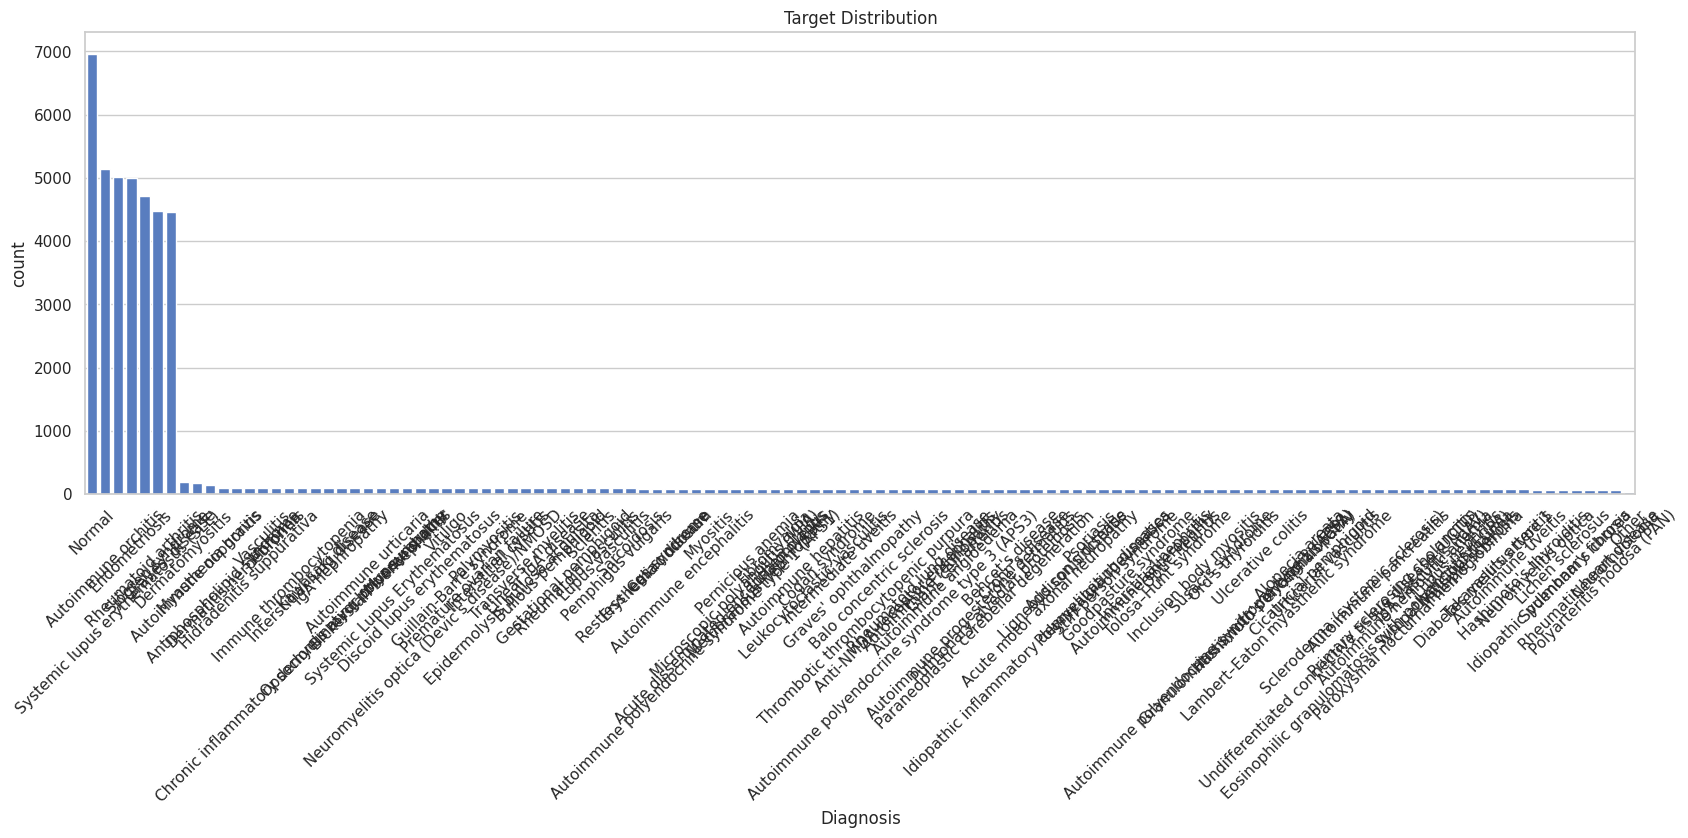

In [4]:
target_col = 'Diagnosis'

print("DISEASE DISTRIBUTION")
display(df[target_col].value_counts())

plt.figure(figsize=(20,6))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.xticks(rotation=45)
plt.title("Target Distribution")
plt.show()

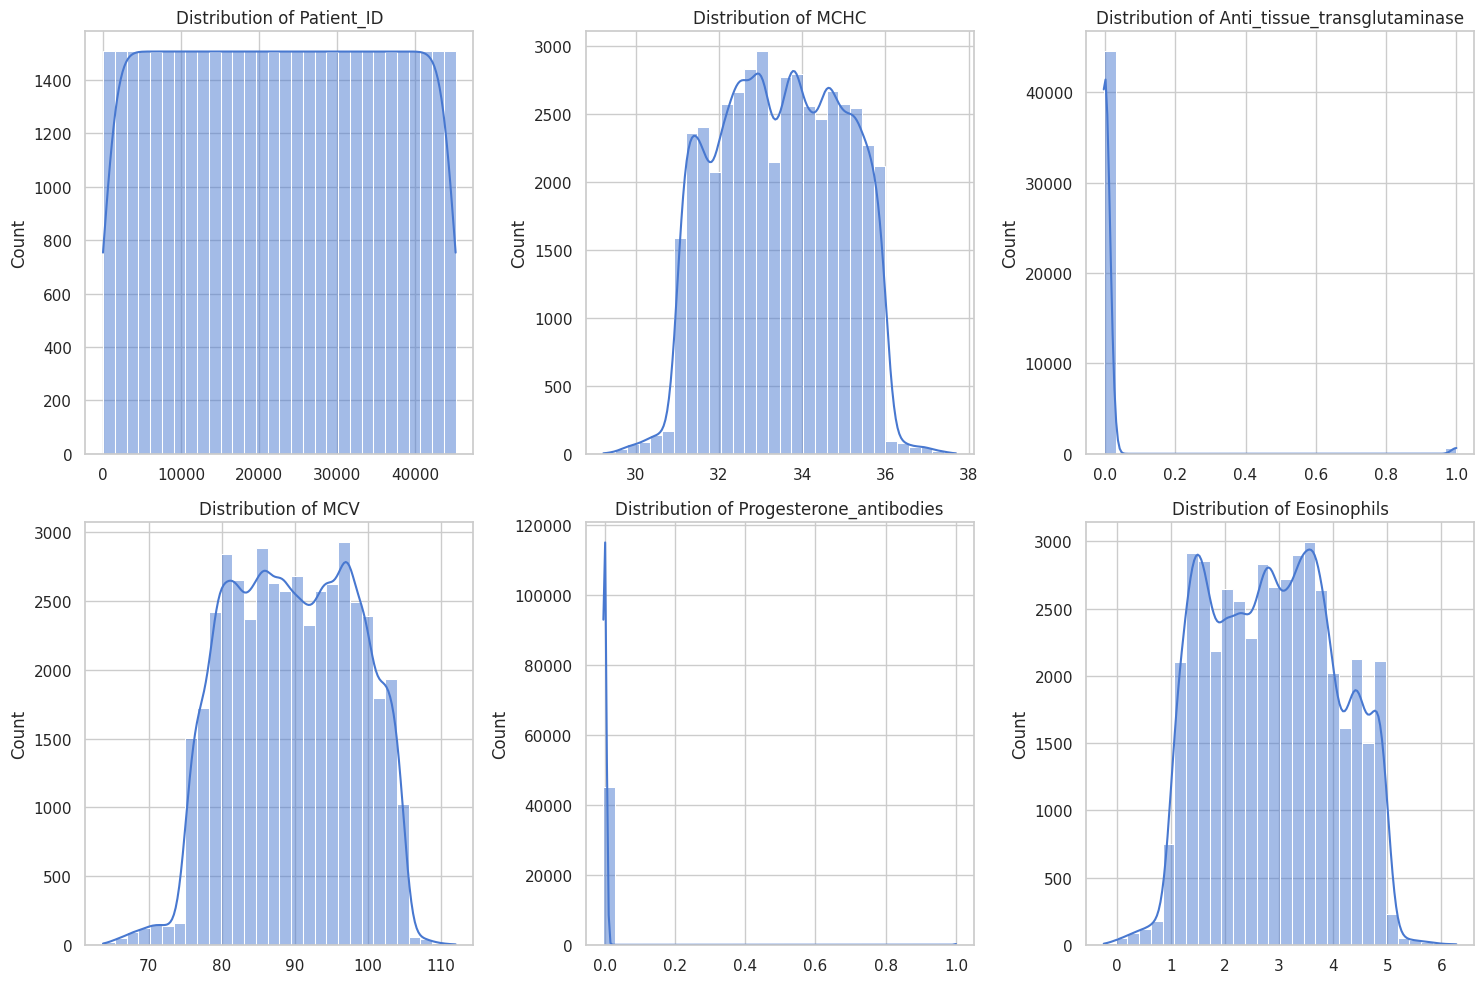

In [5]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

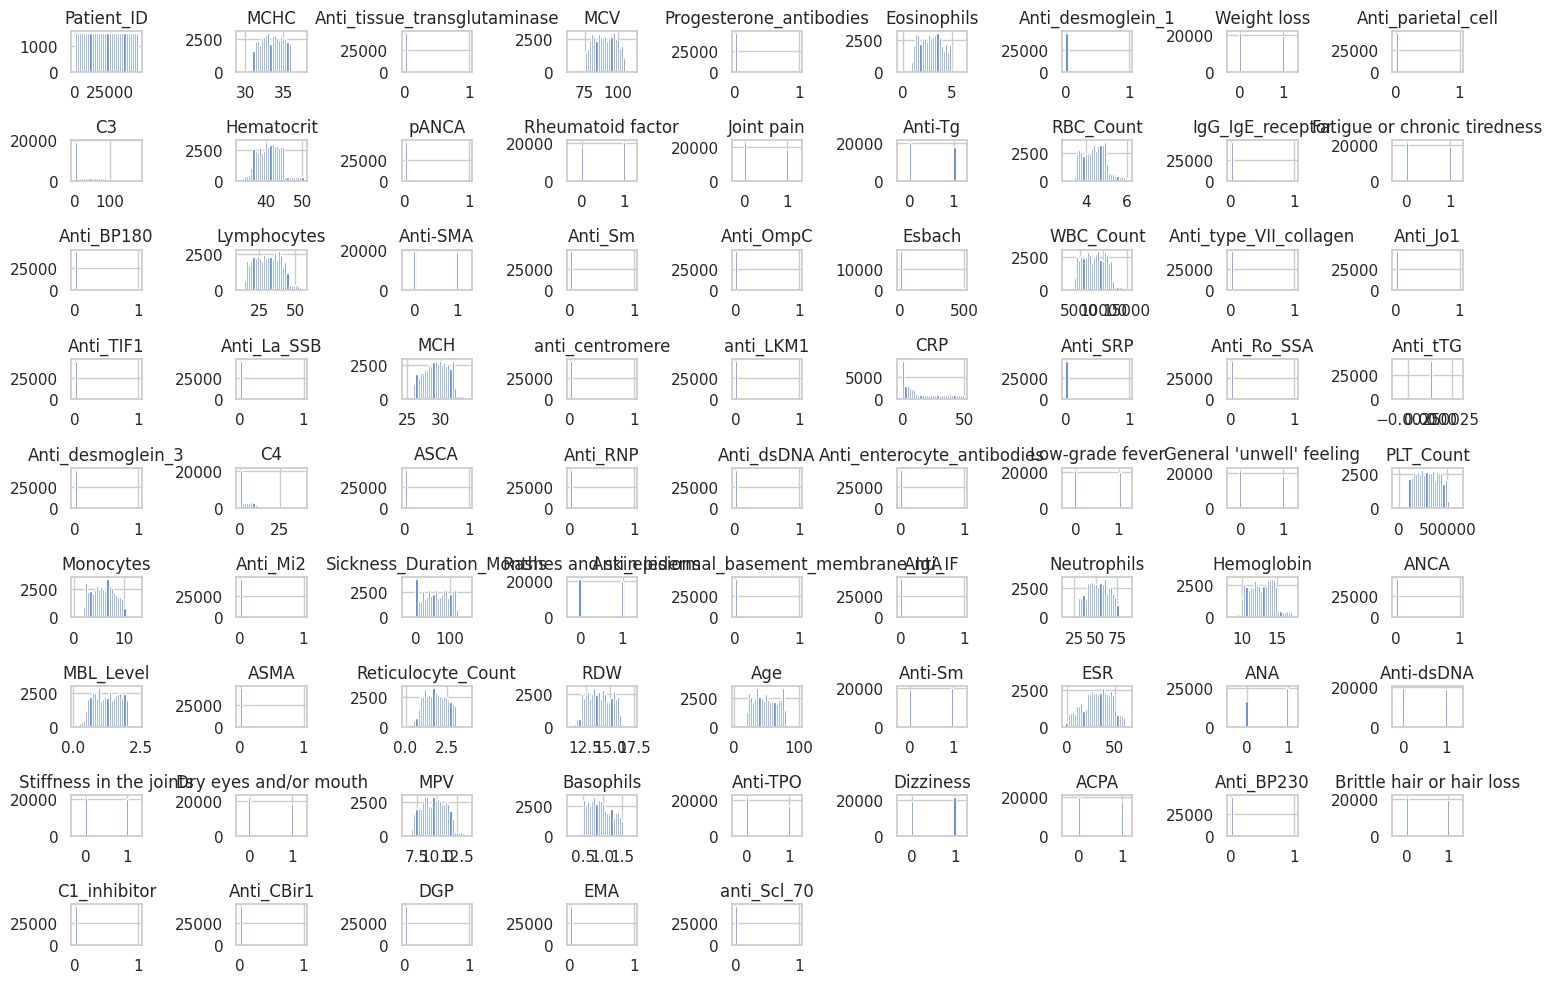

In [6]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()



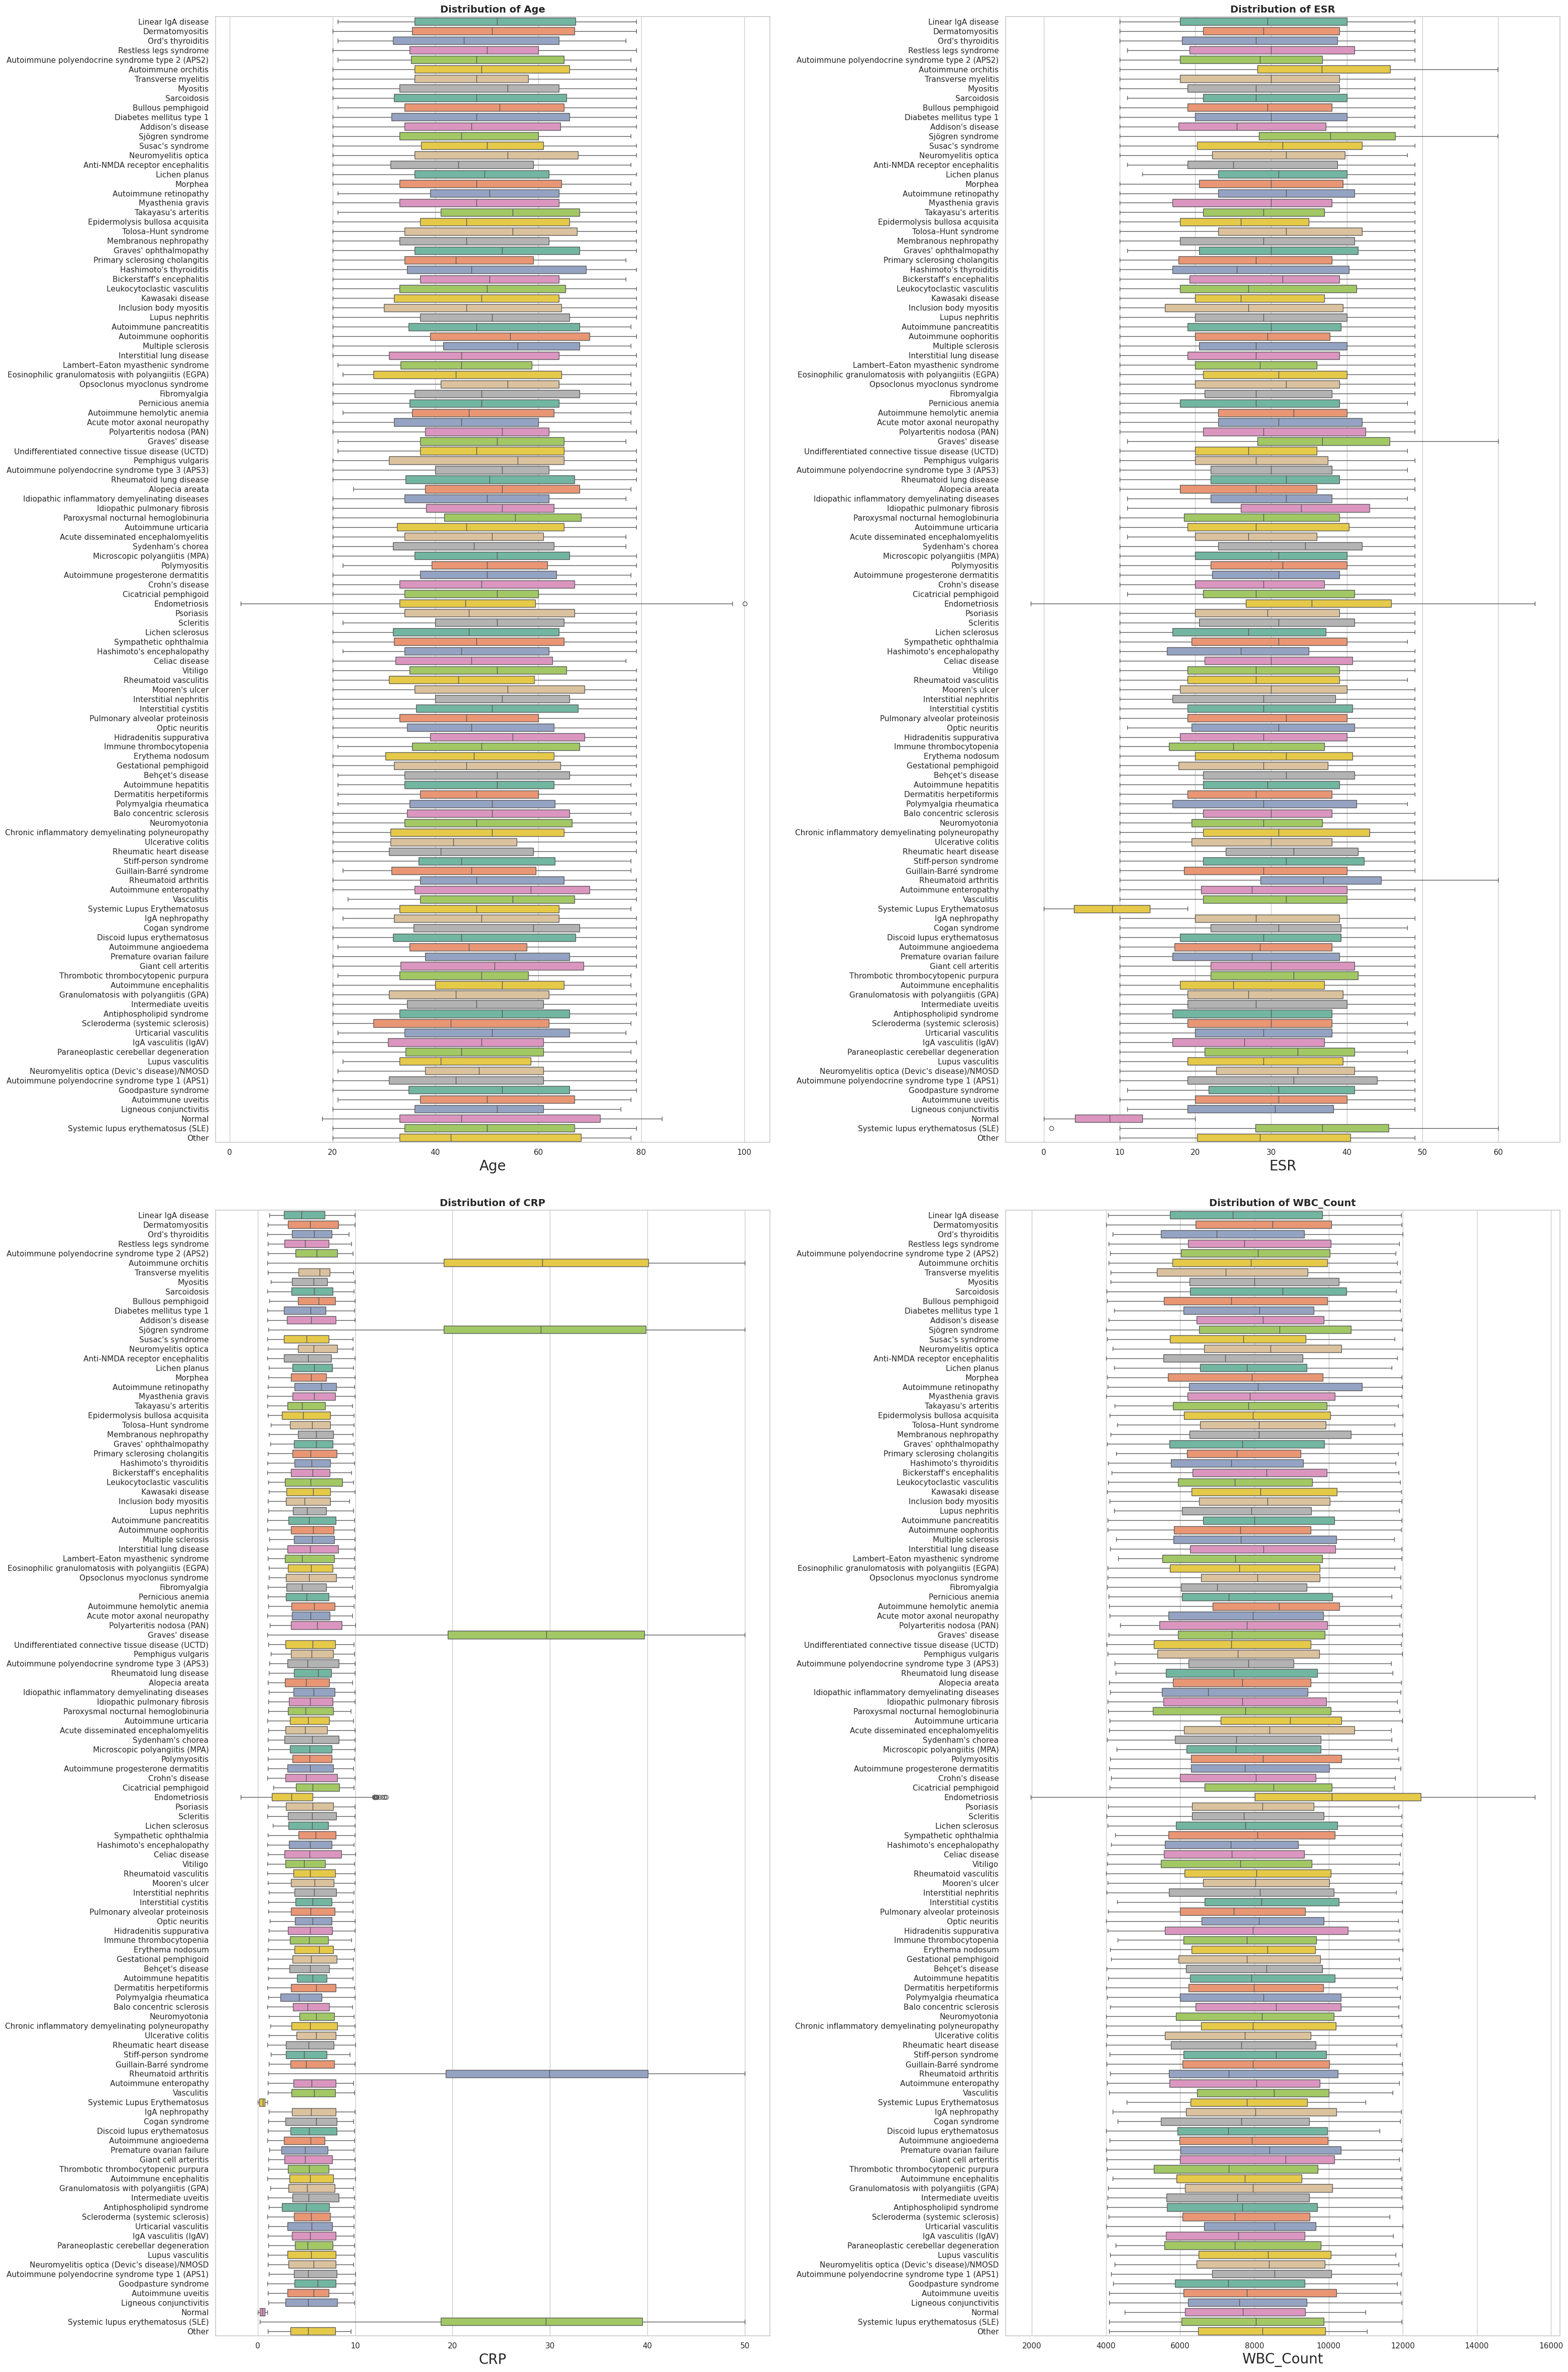

In [7]:
features_to_compare = ['Age', 'ESR', 'CRP', 'WBC_Count']
plt.figure(figsize=(32, 48))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(data=df, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=20)

plt.tight_layout(pad=3.0)
plt.show()

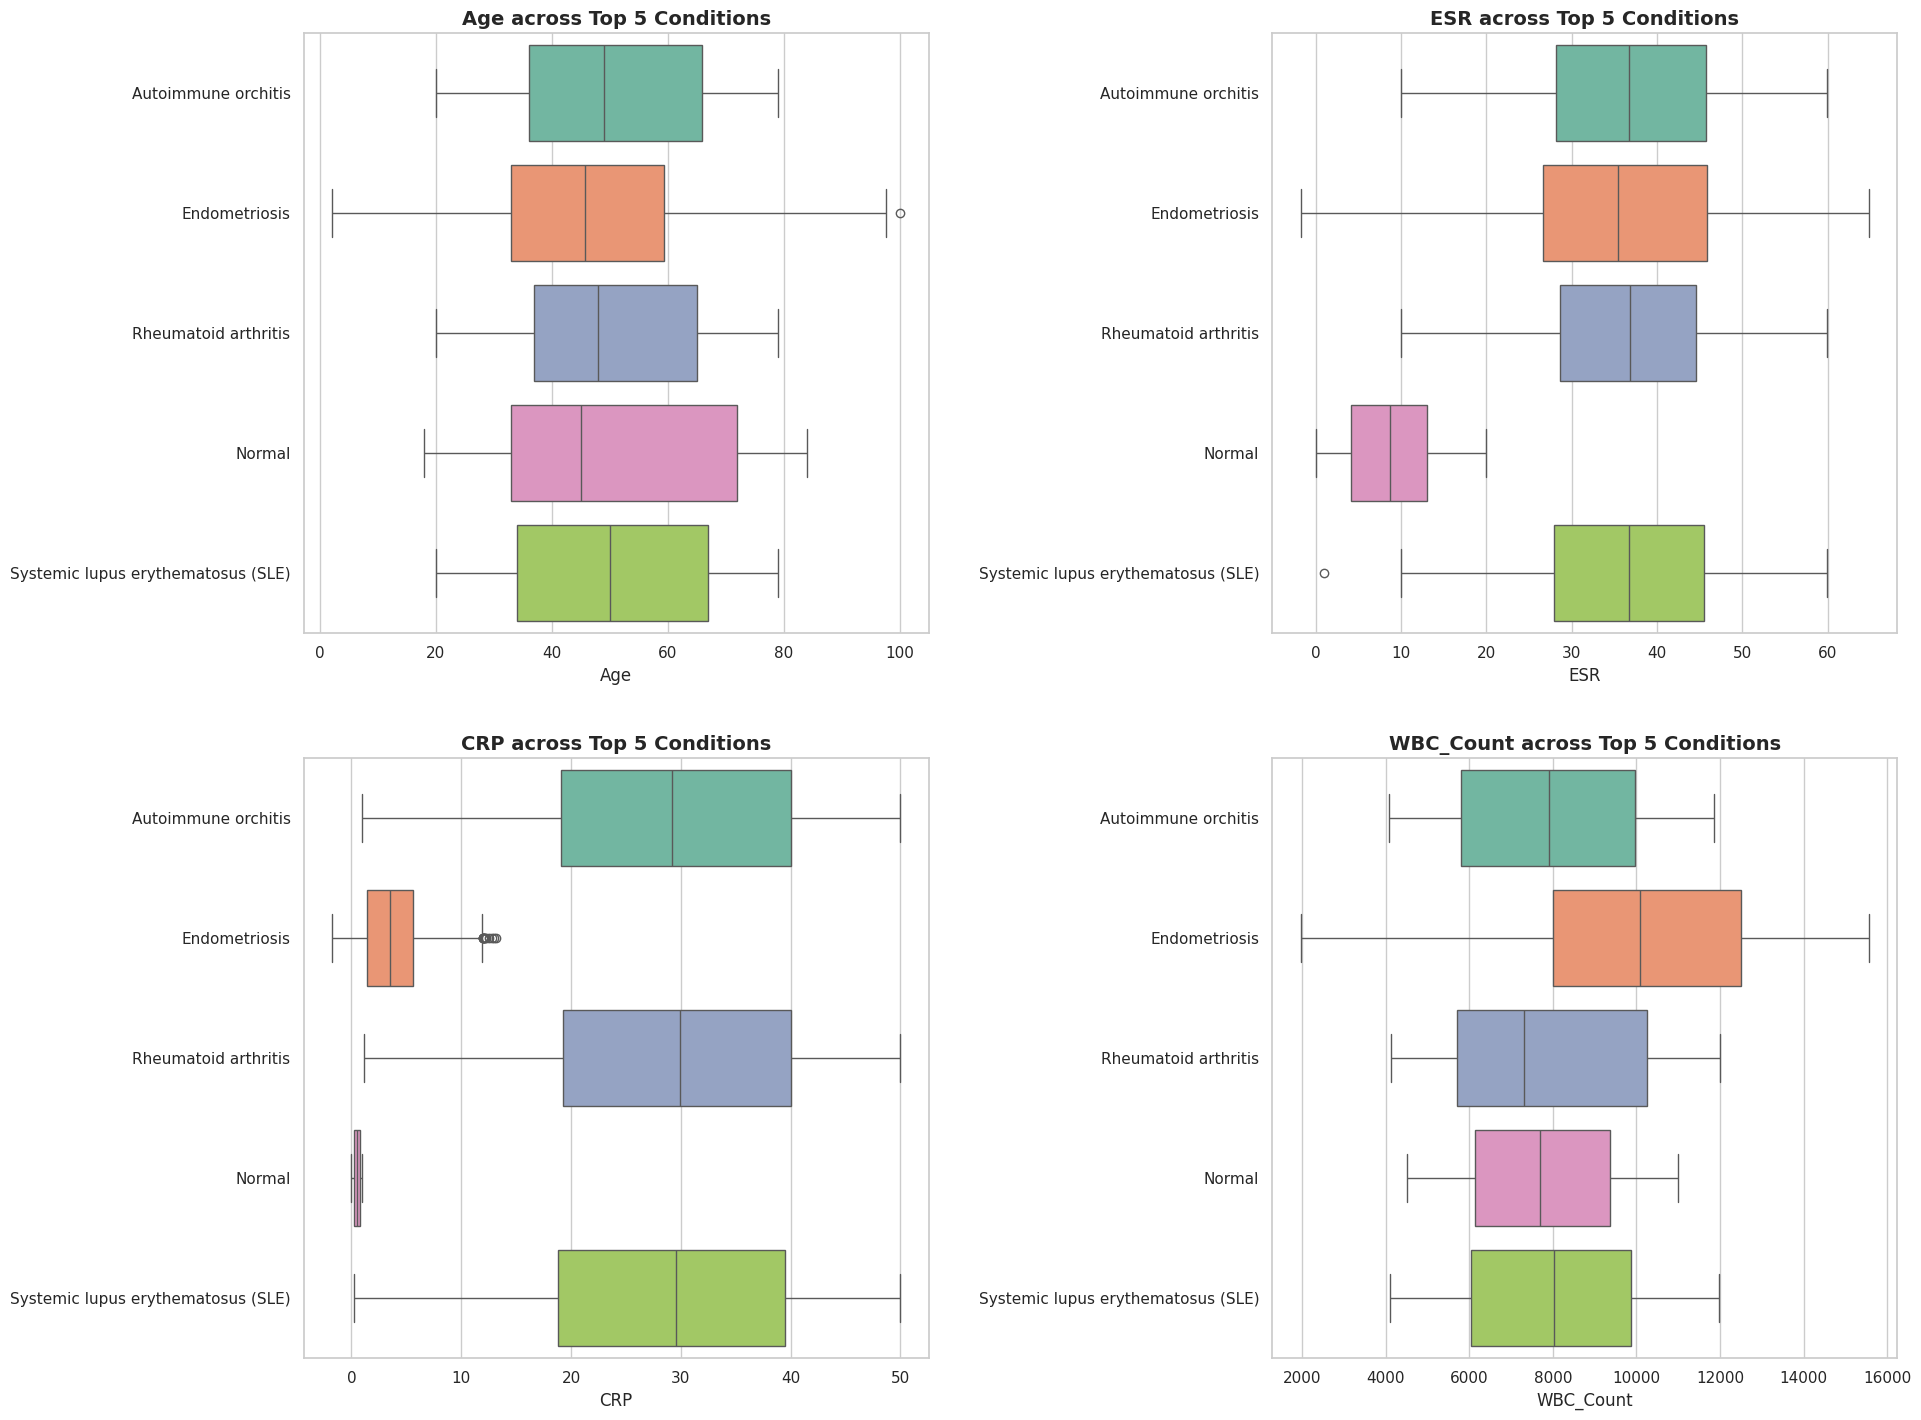

In [8]:
target_col = 'Diagnosis'
features_to_compare = ['Age', 'ESR', 'CRP', 'WBC_Count']

top_5_diseases = df[target_col].value_counts().index[:5]
df_top5 = df[df[target_col].isin(top_5_diseases)]

plt.figure(figsize=(20, 15))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_top5, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)
    plt.title(f'{col} across Top 5 Conditions', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

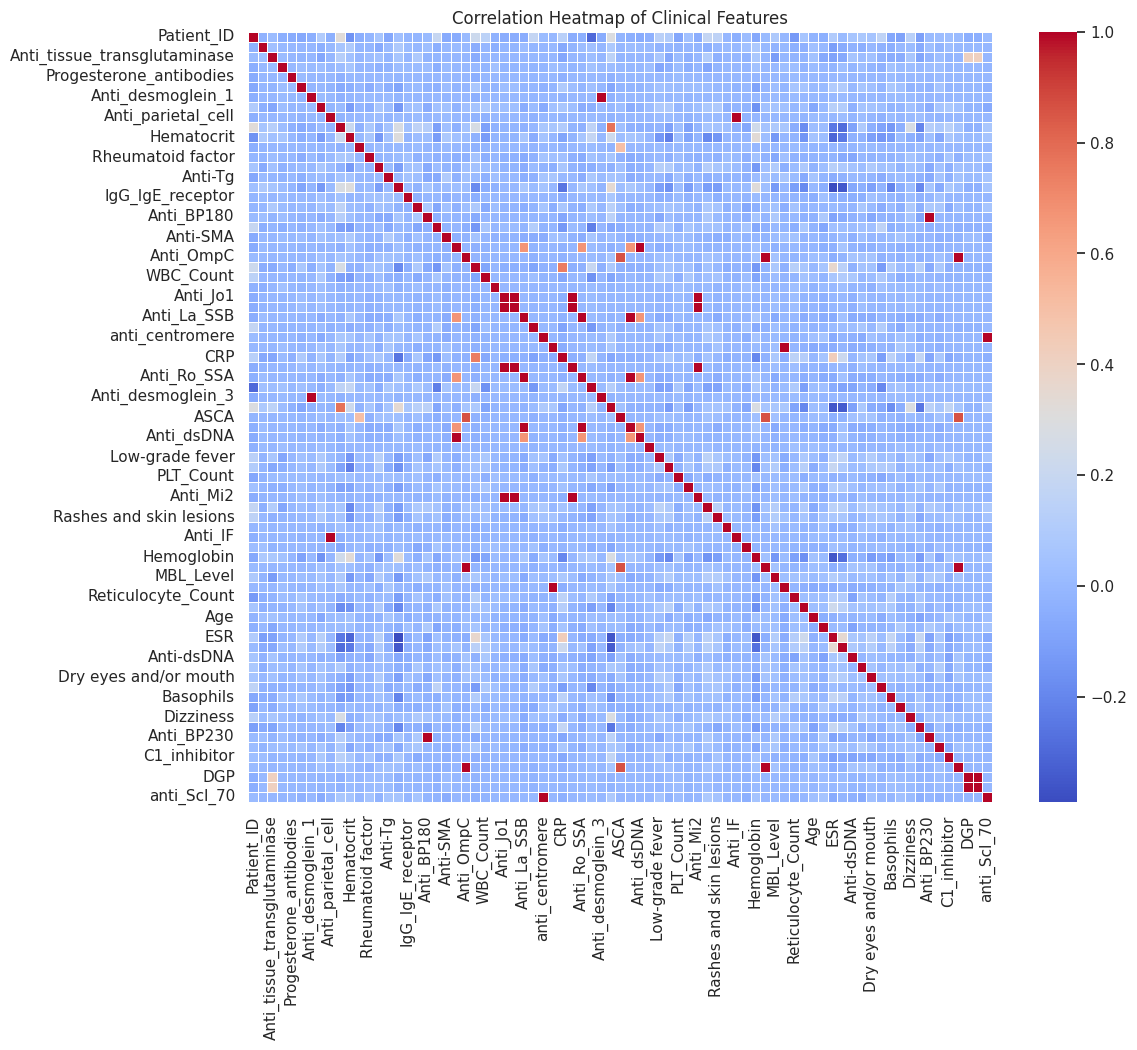

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


In [9]:
plt.figure(figsize=(12, 10))

# بCalculate the correlation matrix for numerical features
corr_matrix = df[num_cols].corr()

#elheatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

In [10]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

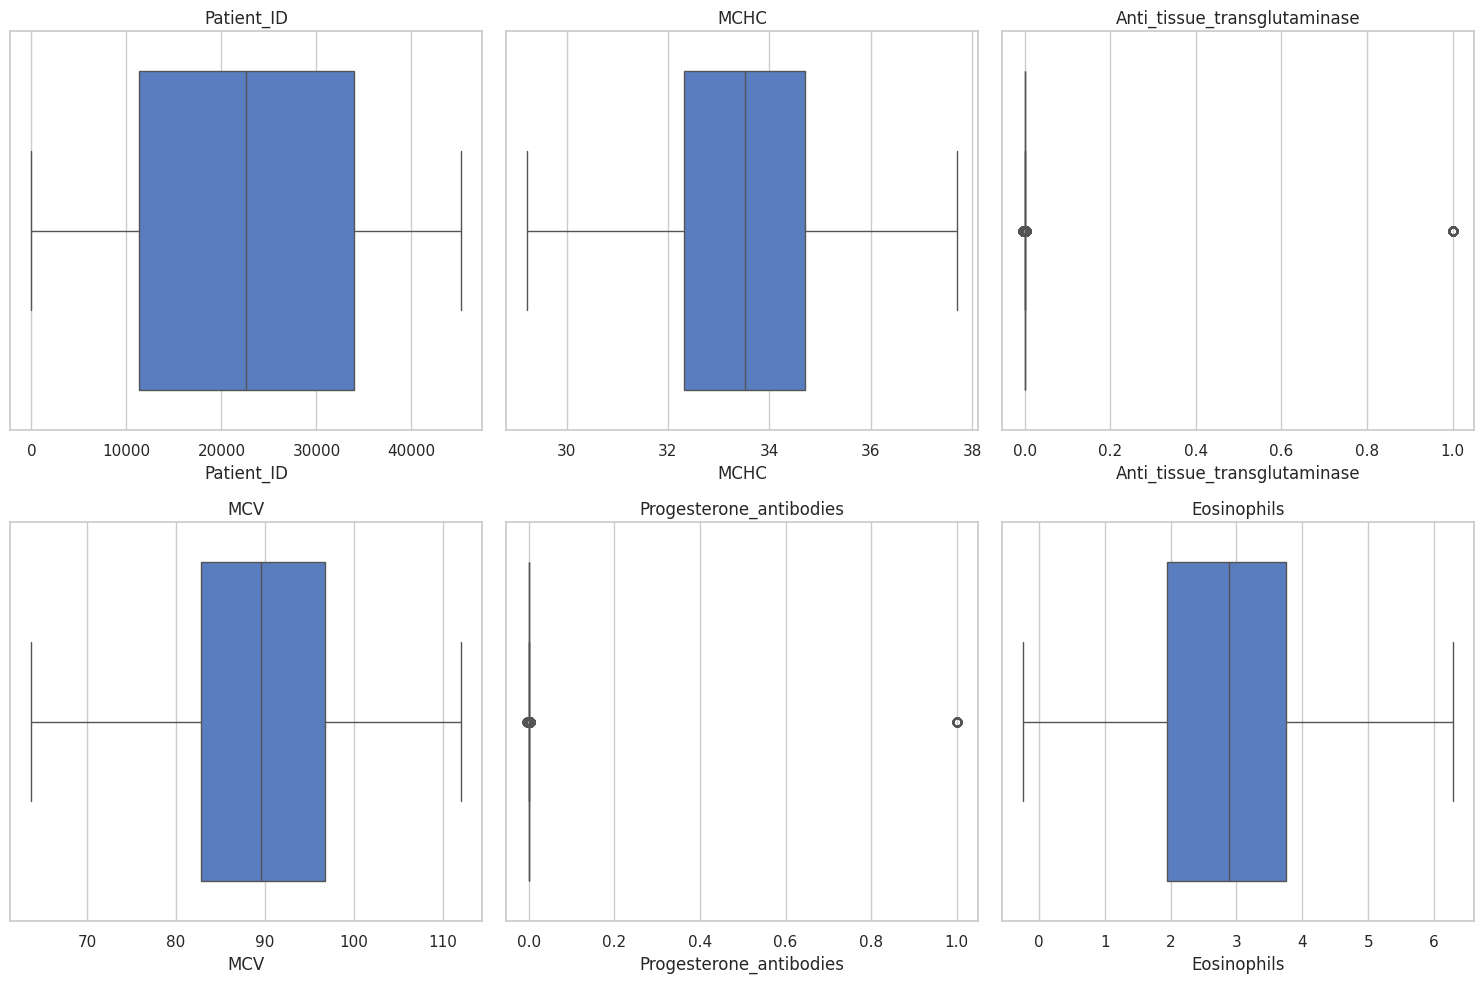

In [11]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


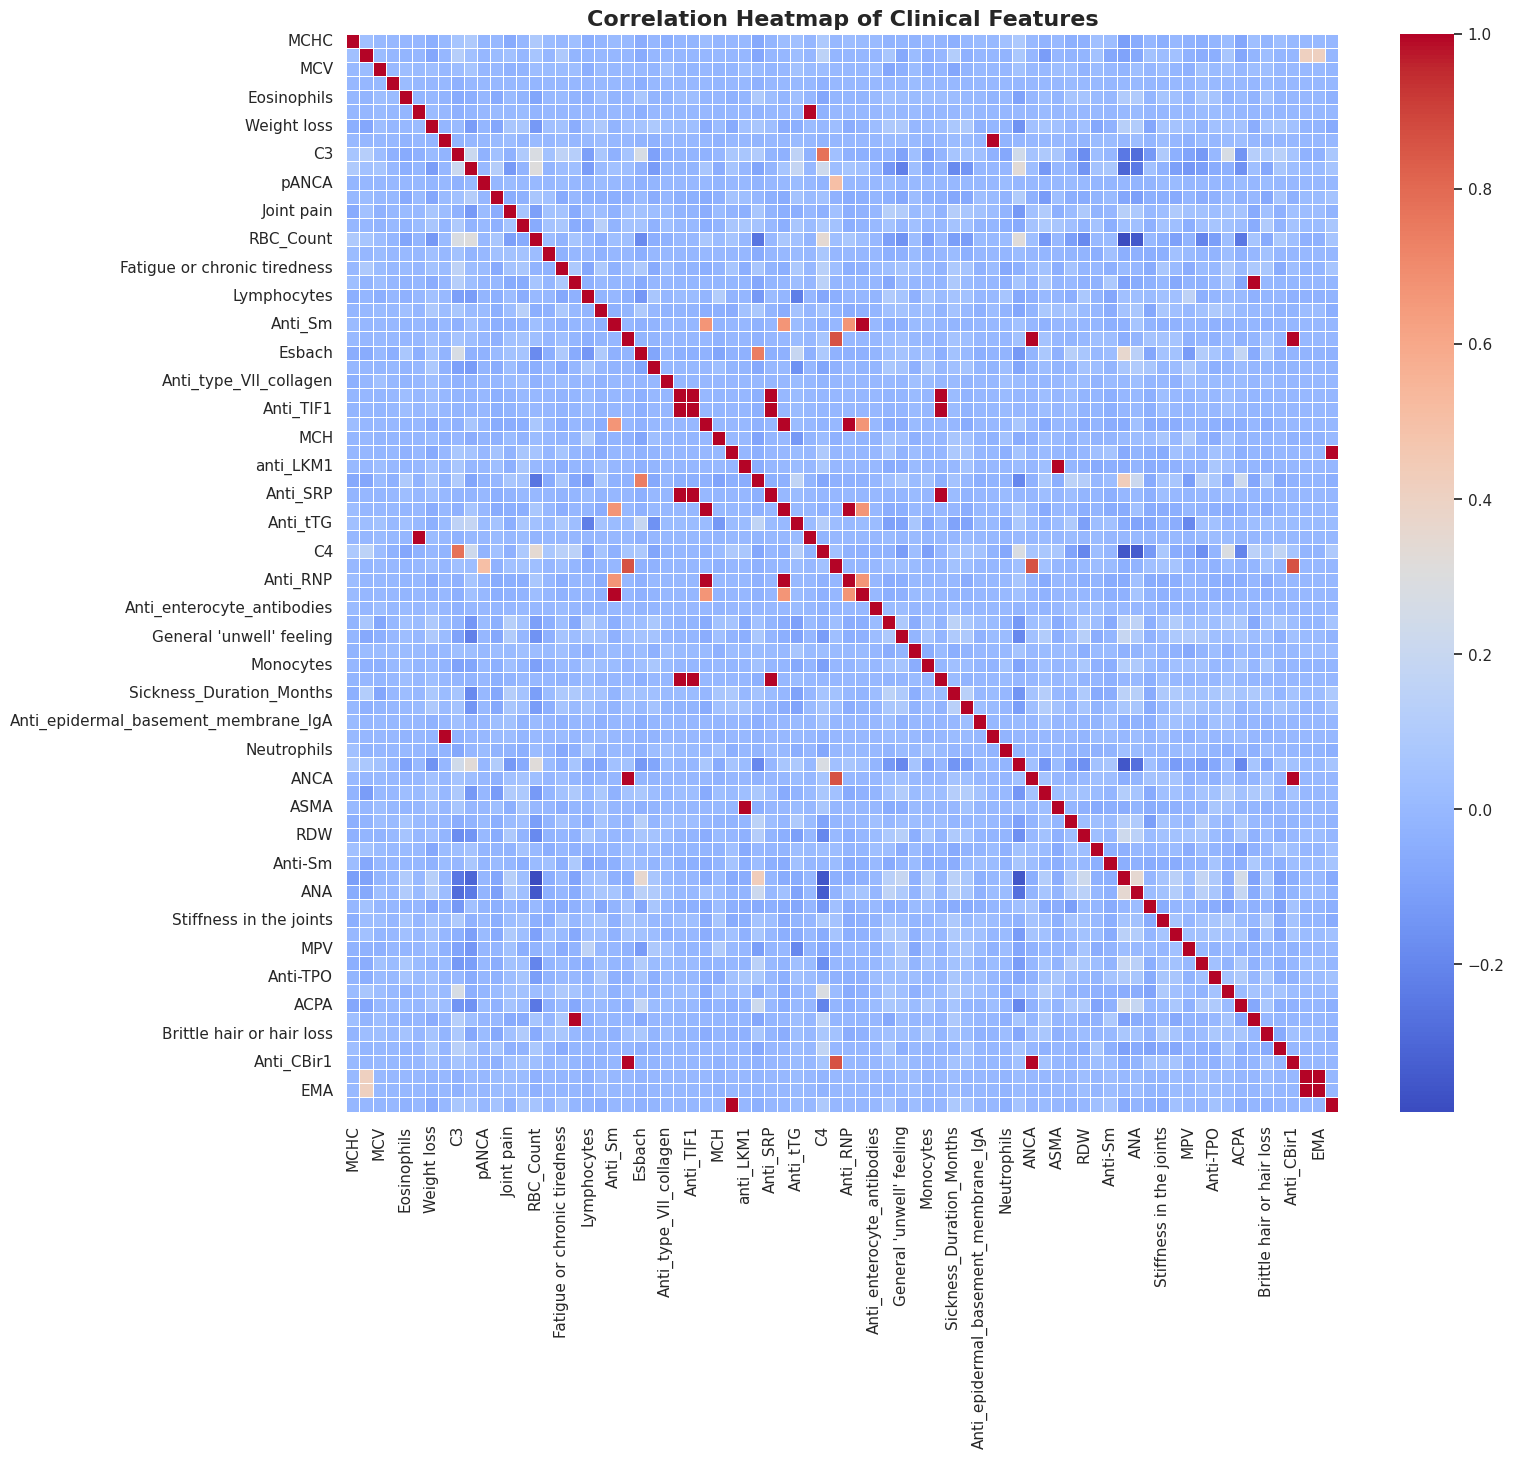

In [12]:
# numerical columns and remove'Patient_ID' as it has no clinical value
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Patient_ID', errors='ignore')

plt.figure(figsize=(16, 14))
corr_matrix = df[num_cols].corr()

#the_heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features', fontsize=16, fontweight='bold')
plt.show()


In [13]:
#highly correlated features (threshold > 0.8)
print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


/tmp/ipykernel_962/3936932106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


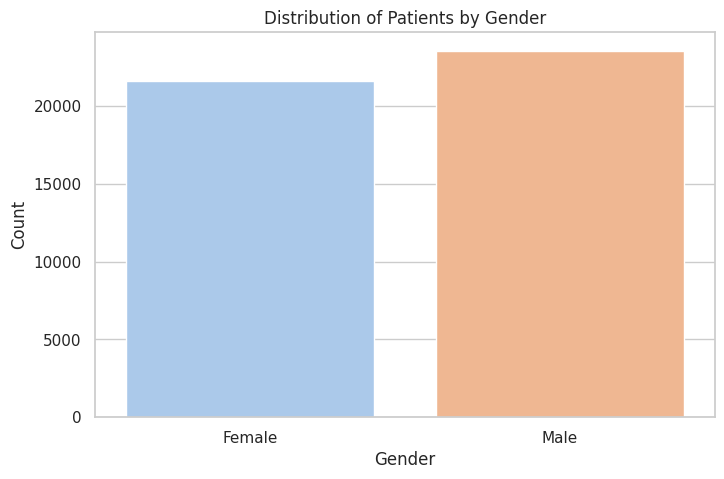

In [14]:
if 'Gender' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Gender', palette='pastel')
    plt.title('Distribution of Patients by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.show()

In [15]:
df_encoded = pd.get_dummies(df.drop(columns=[target_col]), drop_first=False, dtype=int)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded[target_col] = le.fit_transform(df[target_col])


In [16]:
top5 = df_encoded['Diagnosis'].value_counts().nlargest(5).index
df_top5 = df_encoded[df_encoded['Diagnosis'].isin(top5)].copy()

print(f"Samples: {len(df_top5)}")
print(df_top5['Diagnosis'].value_counts())

Samples: 26829
Diagnosis
78     6960
12     5142
108    5016
34     5000
96     4711
Name: count, dtype: int64


In [17]:
target_col = "Diagnosis"


X = df_top5.drop(columns=[target_col])
y = df_top5[target_col]

In [18]:
from sklearn.preprocessing import LabelEncoder

# Filter to top 5
top5 = df['Diagnosis'].value_counts().nlargest(5).index
df_top10 = df[df['Diagnosis'].isin(top5)].copy()
df_top5 = df_top5.reset_index(drop=True)  # reset index after filtering

# Encode target BEFORE get_dummies, separately
le = LabelEncoder()
y = le.fit_transform(df_top5['Diagnosis'])  # directly gives np.array [0,1,...,9]

# Encode features separately, never mix target in
X = pd.get_dummies(df_top5.drop(columns=['Diagnosis']), drop_first=False, dtype=int)

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

print(f"\ny unique values: {sorted(set(y))}")   # must be [0,1,2,...,9]
print(f"X shape: {X.shape}")
print(f"Total samples: {len(y)}")

Class mapping:
  0: 12
  1: 34
  2: 78
  3: 96
  4: 108

y unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
X shape: (26829, 79)
Total samples: 26829


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# AdaBoost requires a base estimator to set tree-specific parameters like max_depth
base_tree = DecisionTreeClassifier(max_depth=6)

model = AdaBoostClassifier(
    estimator=base_tree,  # Note: use 'base_estimator' instead if you are on sklearn < 1.2
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=6),
                   learning_rate=0.1, n_estimators=200, random_state=42)

In [21]:
print(f"Total samples: {len(df)}")
print(f"Number of unique diagnoses: {df['Diagnosis'].nunique()}")
print("\nSamples per class:")
print(df['Diagnosis'].value_counts())
print(f"\nAverage samples per class: {df['Diagnosis'].value_counts().mean():.1f}")

Total samples: 45205
Number of unique diagnoses: 118

Samples per class:
Diagnosis
Normal                                6960
Autoimmune orchitis                   5142
Systemic lupus erythematosus (SLE)    5016
Endometriosis                         5000
Rheumatoid arthritis                  4711
                                      ... 
Sydenham's chorea                       68
Rheumatic heart disease                 67
Polyarteritis nodosa (PAN)              63
Neuromyotonia                           62
Other                                   30
Name: count, Length: 118, dtype: int64

Average samples per class: 383.1


In [22]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"ACC: {acc}")
print(f"Recall (SE): {recall}")
print(f"Precision (PPV): {precision}")
print(f"F1 Score: {f1}")

Confusion Matrix:
 [[1014   13    0    2    0]
 [  11  987    0    2    0]
 [   0    0 1392    0    0]
 [   8   10    0  924    0]
 [   0    0    0    0 1003]]
ACC: 0.9914275065225494
Recall (SE): 0.9914275065225494
Precision (PPV): 0.9914724096281644
F1 Score: 0.9914349938481535


In [23]:
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.9902716874984152


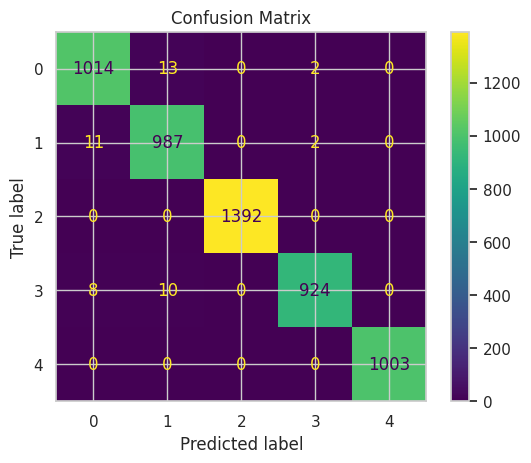

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

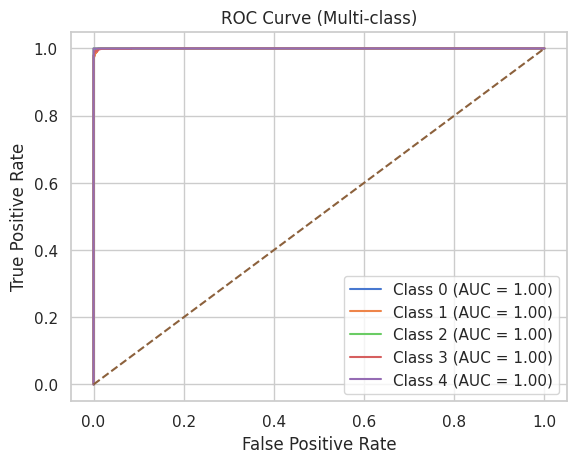

In [25]:

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

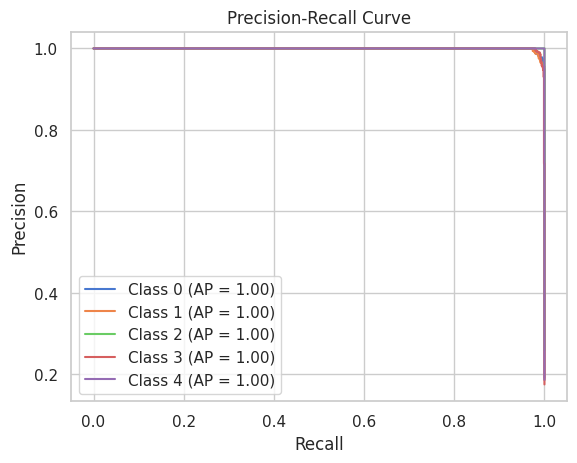

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure()

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])

    plt.plot(recall, precision, label=f"Class {classes[i]} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

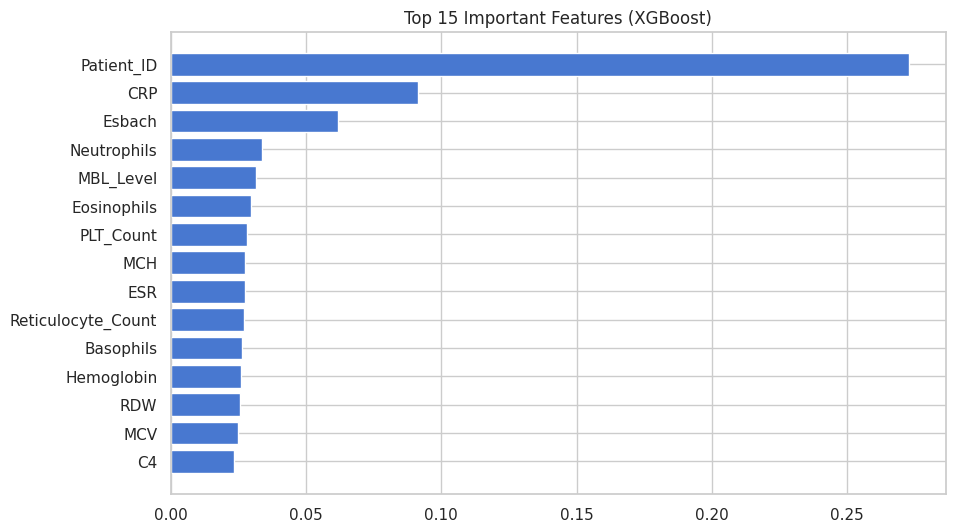

In [27]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:15], feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features (XGBoost)")
plt.show()

In [ ]:
import shap

# Pass model.predict instead of the model itself
# Note: Using a subset of X_train (e.g., 100 rows) is highly recommended
# because black-box explainers (like Permutation or Kernel) are very slow.
background_data = shap.sample(X_train, 100)

explainer = shap.Explainer(model.predict, background_data)
shap_values = explainer(X_test)

PermutationExplainer explainer:  89%|████████▊ | 4750/5366 [1:31:28<12:19,  1.20s/it]

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
top_feature = feat_imp['Feature'].iloc[0]

# Pass the 2D array directly
shap.dependence_plot(top_feature, shap_values.values, X_test)